# Comparison ERA5 data and CMIP6 data

In [1]:
#load libraries
import importlib
import pandas as pd
import xarray as xr
import numpy as np
import datetime as dt
from numpy import nan
from constants import *
import sys
import warnings
import math
import os
import cftime
from glob import glob
from timeit import default_timer as timer # try to measure time


In [2]:
#Colours
blue_dark = "#1f4e79"
blue_main = "#2a6f97"
blue_light = "#61a5c2"
blue_very_light = "#74a9cf"
grey = "#6c757d"

In [3]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load ERA5 data
ds2000_2003 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/wind_gust_00_03')
ds2004_2007 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/wind_gust_04_07')
ds2008_2011 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/wind_gust_08_11')
ds2012_2014 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/wind_gust_12_14')

#Combine datasets
ds_combined = xr.concat(
    [ds2000_2003, ds2004_2007, ds2008_2011, ds2012_2014],
    dim="valid_time"
)

#Get dataframe
df_era = ds_combined.to_dataframe().reset_index()

#Compute daily maxima
df_era_daily = df_era.groupby(
    [df_era['valid_time'].dt.date, 'latitude', 'longitude']
)['fg10'].max().reset_index()

#Change column names
df_era_daily = df_era_daily.rename(columns={
    'valid_time': 'datetime',
    'latitude': 'lat',
    'longitude': 'lon',
    'fg10': 'era_gust_ms'
})

#Correct Datatime
df_era_daily['datetime'] = pd.to_datetime(df_era_daily['datetime'])

print("ERA5 daily max ready")

#Load CMIP6 data
bncmip6 = xr.open_dataset(
    '/Users/anne-sophiesimons/Documents/Data thesis/CMIP6/CNRM-CM6-1/sfcWindmax_day_CNRM-CM6-1_historical_r1i1p1f2_gr_19500101-20141231.nc'
)

#Select Belgium
lat_min, lat_max = 49.5, 51.6
lon_min, lon_max = 2.5, 6.5

ds_cmip6 = bncmip6.sel(
    lat=slice(lat_min, lat_max),
    lon=slice(lon_min, lon_max)
)

#Select winter months
winter_months = [1, 2, 3, 10, 11, 12]

ds_cmip6 = ds_cmip6.sel(
    time=ds_cmip6.time.dt.month.isin(winter_months)
)

#Select period
ds_cmip6 = ds_cmip6.sel(
    time=slice('2000-01-01', '2014-12-31')
)

#To Dataframe
df_cmip6 = ds_cmip6['sfcWindmax'].to_dataframe().reset_index()

#Rename columns
df_cmip6 = df_cmip6.rename(columns={
    'time': 'datetime',
    'sfcWindmax': 'cmip6_gust_ms'
})

df_cmip6['datetime'] = pd.to_datetime(df_cmip6['datetime'])

print("CMIP6 ready")

#Interpolate ERA5 to CMIP6 grid
#ERA5 to xarray
ds_era_daily = xr.Dataset.from_dataframe(
    df_era_daily.set_index(['datetime', 'lat', 'lon'])
)

era_da = ds_era_daily['era_gust_ms']

#Get CMIP6 grid
lat_out = ds_cmip6['lat']
lon_out = ds_cmip6['lon']

#Interpolation
era_interp = era_da.interp(
    lat=lat_out,
    lon=lon_out,
    method='linear',
    kwargs={"fill_value": "extrapolate"}
)

#To dataframe
df_era_interp = era_interp.to_dataframe().reset_index()

print("Interpolation ready")

#Make data consistent
#Datatime to day
df_era_interp['datetime'] = pd.to_datetime(df_era_interp['datetime']).dt.floor('D')
df_cmip6['datetime'] = pd.to_datetime(df_cmip6['datetime']).dt.floor('D')

#Round lat and lon
df_era_interp['lat'] = df_era_interp['lat'].round(4)
df_era_interp['lon'] = df_era_interp['lon'].round(4)

df_cmip6['lat'] = df_cmip6['lat'].round(4)
df_cmip6['lon'] = df_cmip6['lon'].round(4)

#Drop NaNs
df_era_interp = df_era_interp.dropna()
df_cmip6 = df_cmip6.dropna()

#Merge
df_merged = pd.merge(
    df_era_interp,
    df_cmip6,
    on=['datetime', 'lat', 'lon'],
    how='inner'
)

df_merged = df_merged.dropna()

print("Merge done:", len(df_merged))

df_merged

ERA5 daily max ready
CMIP6 ready
Interpolation ready
Merge done: 16404


,datetime,lat,lon,height_x,era_gust_ms,height_y,cmip6_gust_ms
0,2000-01-01,49.7271,2.8125,10.0,5.549057,10.0,4.202200
1,2000-01-01,49.7271,4.2188,10.0,5.207371,10.0,3.567337
2,2000-01-01,49.7271,5.6250,10.0,6.558376,10.0,3.734020
3,2000-01-01,51.1279,2.8125,10.0,7.272290,10.0,6.338283
4,2000-01-01,51.1279,4.2188,10.0,6.582111,10.0,5.063760
...,...,...,...,...,...,...,...
16399,2014-12-31,49.7271,4.2188,10.0,2.909762,10.0,1.622752
16400,2014-12-31,49.7271,5.6250,10.0,5.108591,10.0,1.942452
16401,2014-12-31,51.1279,2.8125,10.0,8.410292,10.0,5.150459
16402,2014-12-31,51.1279,4.2188,10.0,6.031333,10.0,5.109186


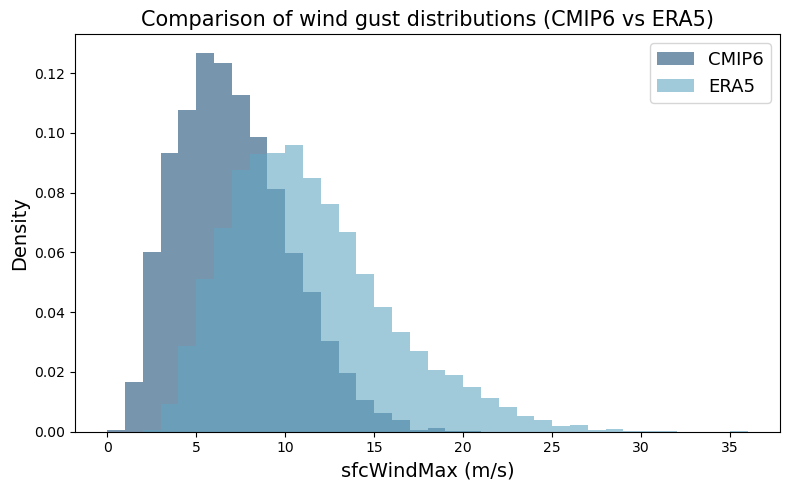

In [5]:
#Plot data
plot_df = df_merged.copy()

fig, ax = plt.subplots(figsize=(8, 5))

bins = np.arange(0, max(plot_df["cmip6_gust_ms"].max(), plot_df["era_gust_ms"].max()) + 1, 1)

ax.hist(
    plot_df["cmip6_gust_ms"],
    bins=bins,
    alpha=0.6,
    density=True,
    color=blue_dark,
    label="CMIP6"
)

ax.hist(
    plot_df["era_gust_ms"],
    bins=bins,
    alpha=0.6,
    density=True,
    color=blue_light,
    label="ERA5"
)

ax.set_xlabel("sfcWindMax (m/s)", fontsize = 14)
ax.set_ylabel("Density", fontsize = 14)
ax.set_title("Comparison of wind gust distributions (CMIP6 vs ERA5)", fontsize = 15)
ax.legend(fontsize = 13)

plt.tight_layout()
plt.savefig("/Users/anne-sophiesimons/Documents/Data thesis/distributions", dpi=300)
plt.show()

In [6]:
import xarray as xr
import numpy as np
import pandas as pd


#Load ERA5 data
ds2000_2003 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/wind_gust_00_03')
ds2004_2007 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/wind_gust_04_07')
ds2008_2011 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/wind_gust_08_11')
ds2012_2014 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/wind_gust_12_14')

#Combine datasets
ds_combined = xr.concat(
    [ds2000_2003, ds2004_2007, ds2008_2011, ds2012_2014],
    dim="valid_time"
)

df_era = ds_combined.to_dataframe().reset_index()

df_era_daily = df_era.groupby(
    [df_era['valid_time'].dt.date, 'latitude', 'longitude']
)['fg10'].max().reset_index()

df_era_daily = df_era_daily.rename(columns={
    'valid_time': 'datetime',
    'latitude': 'lat',
    'longitude': 'lon',
    'fg10': 'era_gust_ms'
})

df_era_daily['datetime'] = pd.to_datetime(df_era_daily['datetime'])


#Load historical CMIP6 data
cmip6 = xr.open_dataset(
    '/Users/anne-sophiesimons/Documents/Data thesis/CMIP6/CNRM-CM6-1/sfcWindmax_day_CNRM-CM6-1_historical_r1i1p1f2_gr_19500101-20141231.nc'
)

lat_min, lat_max = 49.5, 51.6
lon_min, lon_max = 2.5, 6.5

ds_cmip6 = cmip6.sel(
    lat=slice(lat_min, lat_max),
    lon=slice(lon_min, lon_max)
)

ds_cmip6 = ds_cmip6.sel(
    time=ds_cmip6.time.dt.month.isin([1,2,3,10,11,12])
)

ds_cmip6 = ds_cmip6.sel(
    time=slice('2000-01-01', '2014-12-31')
)

df_cmip6 = ds_cmip6['sfcWindmax'].to_dataframe().reset_index()

df_cmip6 = df_cmip6.rename(columns={
    'time': 'datetime',
    'sfcWindmax': 'cmip6_gust_ms'
})

df_cmip6['datetime'] = pd.to_datetime(df_cmip6['datetime'])


#Load bias corrected CMIP6
bias_ds = xr.load_dataset(
    '/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/bias_corr_historical_1'
)

bias_ds = bias_ds.sel(
    valid_time=slice(np.datetime64('2000-01-01'), np.datetime64('2015-01-01'))
)

df_cmip6_bias = bias_ds['historical'].to_dataframe().reset_index()

df_cmip6_bias = df_cmip6_bias.rename(columns={
    'valid_time': 'datetime',
    'historical': 'cmip6_bc_gust_ms',
    'latitude': 'lat',
    'longitude': 'lon'
})

df_cmip6_bias['datetime'] = pd.to_datetime(df_cmip6_bias['datetime'])


#Interpolate ERA5 to CMIP6 grid
ds_era = xr.Dataset.from_dataframe(
    df_era_daily.set_index(['datetime', 'lat', 'lon'])
)

era_interp = ds_era['era_gust_ms'].interp(
    lat=ds_cmip6['lat'],
    lon=ds_cmip6['lon'],
    method='linear',
    kwargs={"fill_value": "extrapolate"}
)

df_era_interp = era_interp.to_dataframe().reset_index()


#Clean data
for df in [df_era_interp, df_cmip6, df_cmip6_bias]:
    df['datetime'] = pd.to_datetime(df['datetime']).dt.floor('D')
    df['lat'] = df['lat'].round(4)
    df['lon'] = df['lon'].round(4)
    df.dropna(inplace=True)


#Merge all three datasets
df_merged_all = df_era_interp.merge(
    df_cmip6,
    on=['datetime', 'lat', 'lon'],
    how='inner'
).merge(
    df_cmip6_bias,
    on=['datetime', 'lat', 'lon'],
    how='inner'
)

df_merged_all

,datetime,lat,lon,height_x,era_gust_ms,height_y,cmip6_gust_ms,member,cmip6_bc_gust_ms
0,2000-01-01,49.7271,2.8125,10.0,5.549057,10.0,4.202200,0,7.069663
1,2000-01-01,49.7271,4.2188,10.0,5.207371,10.0,3.567337,0,6.960622
2,2000-01-01,49.7271,5.6250,10.0,6.558376,10.0,3.734020,0,7.678907
3,2000-01-01,51.1279,2.8125,10.0,7.272290,10.0,6.338283,0,9.310425
4,2000-01-01,51.1279,4.2188,10.0,6.582111,10.0,5.063760,0,7.506104
...,...,...,...,...,...,...,...,...,...
16399,2014-12-31,49.7271,4.2188,10.0,2.909762,10.0,1.622752,0,3.931855
16400,2014-12-31,49.7271,5.6250,10.0,5.108591,10.0,1.942452,0,4.749616
16401,2014-12-31,51.1279,2.8125,10.0,8.410292,10.0,5.150459,0,7.932439
16402,2014-12-31,51.1279,4.2188,10.0,6.031333,10.0,5.109186,0,7.559949


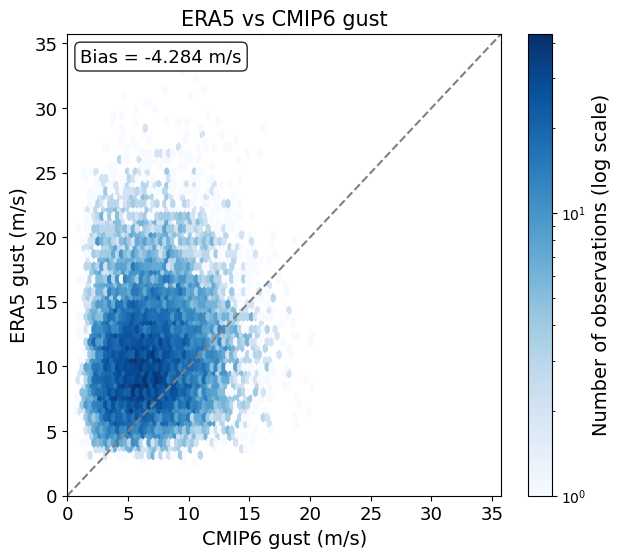

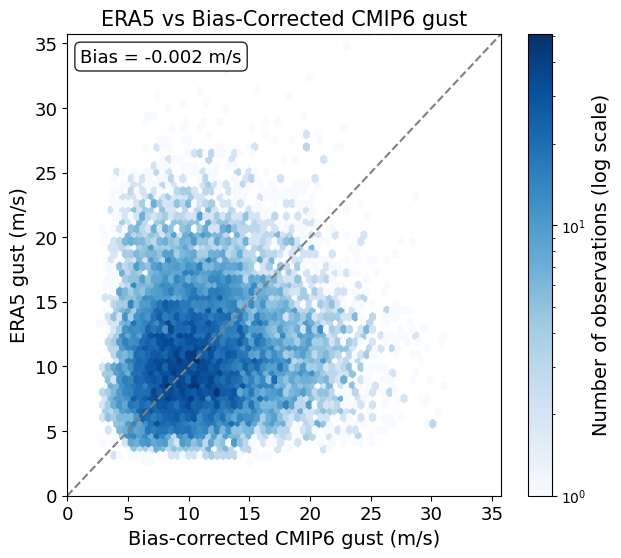

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error


#Function for statistics
def calc_stats(x, y):
    diff = x - y  # bias = CMIP6 - ERA5
    bias = diff.mean()
    rmse = np.sqrt(mean_squared_error(y, x))
    corr = x.corr(y)
    return corr, bias, rmse


#Data
df = df_merged_all.dropna()


#Statistics
corr_all, bias_all, rmse_all = calc_stats(
    df["cmip6_gust_ms"],
    df["era_gust_ms"]
)

corr_bc, bias_bc, rmse_bc = calc_stats(
    df["cmip6_bc_gust_ms"],
    df["era_gust_ms"]
)


#Common scale
max_val = max(
    df["cmip6_gust_ms"].max(),
    df["cmip6_bc_gust_ms"].max(),
    df["era_gust_ms"].max()
)



#Figure 1: CMIP6 VS ERA5
fig1, ax1 = plt.subplots(figsize=(7, 6))

hb1 = ax1.hexbin(
    df["cmip6_gust_ms"],
    df["era_gust_ms"],
    gridsize=60,
    mincnt=1,
    cmap="Blues",
    bins="log"
)

ax1.plot([0, max_val], [0, max_val], linestyle="--", color="grey", linewidth=1.5)

ax1.set_xlim(0, max_val)
ax1.set_ylim(0, max_val)

ax1.set_xlabel("CMIP6 gust (m/s)", fontsize = 14)
ax1.set_ylabel("ERA5 gust (m/s)", fontsize = 14)
ax1.set_title("ERA5 vs CMIP6 gust", fontsize = 15)
ax1.tick_params(axis='both', labelsize=13)

ax1.text(
    0.03, 0.97,
    f"Bias = {bias_all:.3f} m/s",
    transform=ax1.transAxes,
    verticalalignment="top",
    fontsize = 13,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
)

fig1.colorbar(hb1, ax=ax1).set_label("Number of observations (log scale)", fontsize = 14)

fig1.savefig("/Users/anne-sophiesimons/Documents/Data thesis/scatter_cmip6.png", dpi=300)
#plt.close(fig1)


#Figure 2: Bias corrected CMIP6 VS ERA5
fig2, ax2 = plt.subplots(figsize=(7, 6))

hb2 = ax2.hexbin(
    df["cmip6_bc_gust_ms"],
    df["era_gust_ms"],
    gridsize=60,
    mincnt=1,
    cmap="Blues",
    bins="log"
)

ax2.plot([0, max_val], [0, max_val], linestyle="--", color="grey", linewidth=1.5)

ax2.set_xlim(0, max_val)
ax2.set_ylim(0, max_val)

ax2.set_xlabel("Bias-corrected CMIP6 gust (m/s)", fontsize = 14)
ax2.set_ylabel("ERA5 gust (m/s)", fontsize = 14)
ax2.set_title("ERA5 vs Bias-Corrected CMIP6 gust", fontsize = 15)
ax2.tick_params(axis='both', labelsize=13)

ax2.text(
    0.03, 0.97,
    f"Bias = {bias_bc:.3f} m/s",
    transform=ax2.transAxes,
    verticalalignment="top",
    fontsize = 13,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
)

fig2.colorbar(hb2, ax=ax2).set_label("Number of observations (log scale)", fontsize = 14)

fig2.savefig("/Users/anne-sophiesimons/Documents/Data thesis/scatter_bias_corrected.png", dpi=300)

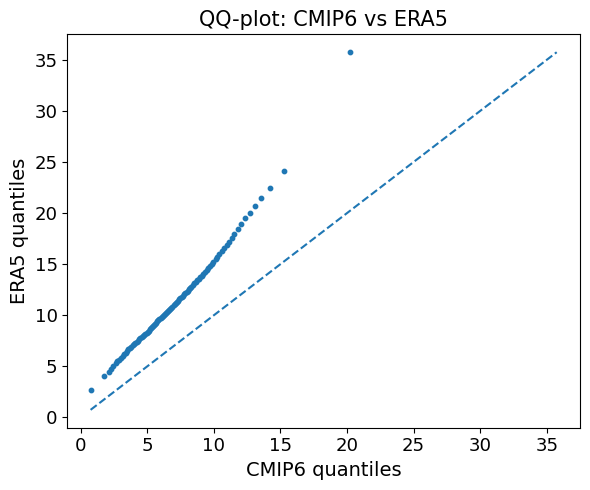

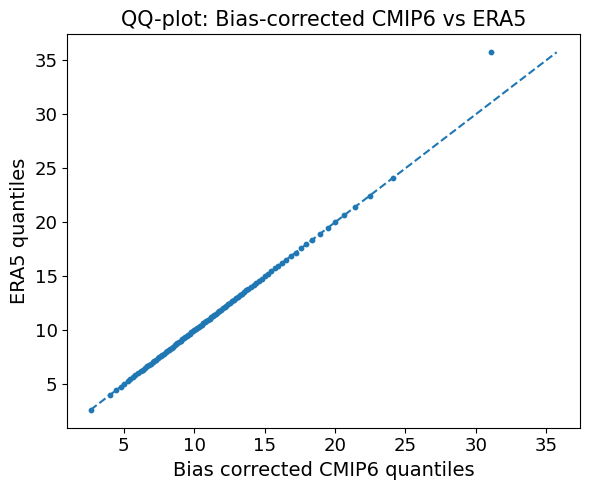

In [14]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = df_merged_all.dropna()

q = np.linspace(0, 1, 100)


#Figure 1: CMIP6 vs ERA5
fig1, ax1 = plt.subplots(figsize=(6, 5))

x = plot_df["cmip6_gust_ms"]
y = plot_df["era_gust_ms"]

x_q = np.quantile(x, q)
y_q = np.quantile(y, q)

ax1.scatter(x_q, y_q, s=10)

min_val = min(x_q.min(), y_q.min())
max_val = max(x_q.max(), y_q.max())

ax1.plot([min_val, max_val], [min_val, max_val], '--')

ax1.set_title("QQ-plot: CMIP6 vs ERA5", fontsize = 15)
ax1.set_xlabel("CMIP6 quantiles", fontsize = 14)
ax1.set_ylabel("ERA5 quantiles", fontsize = 14)
ax1.tick_params(axis='both', labelsize=13)

fig1.tight_layout()
fig1.savefig("/Users/anne-sophiesimons/Documents/Data thesis/QQ_CMIP6.png", dpi=300)
#plt.close(fig1)

#Figure 2: Bias-corrected CMIP6 vs ERA5
fig2, ax2 = plt.subplots(figsize=(6, 5))

x = plot_df["cmip6_bc_gust_ms"]
y = plot_df["era_gust_ms"]

x_q = np.quantile(x, q)
y_q = np.quantile(y, q)

ax2.scatter(x_q, y_q, s=10)

min_val = min(x_q.min(), y_q.min())
max_val = max(x_q.max(), y_q.max())

ax2.plot([min_val, max_val], [min_val, max_val], '--')

ax2.set_title("QQ-plot: Bias-corrected CMIP6 vs ERA5", fontsize = 15)
ax2.set_xlabel("Bias corrected CMIP6 quantiles", fontsize = 14)
ax2.set_ylabel("ERA5 quantiles", fontsize = 14)
ax2.tick_params(axis='both', labelsize=13)

fig2.tight_layout()
fig2.savefig("/Users/anne-sophiesimons/Documents/Data thesis/QQ_BC.png", dpi=300)
#plt.close(fig2)

In [16]:
##HIER WORDT ALLE DATA INGELEZEN VAN 2015 TOT EN MET 2100!!!
#ERA5 en CMIP6 data inlezen, ERA5 data interpoleren naar CMIP6 grid cells en mergen naar 1 bestand
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Load CMIP6 data under future projection SSP585
bncmip6_ssp585 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/CMIP6/CNRM-CM6-1/sfcWindmax_day_CNRM-CM6-1_ssp585_r1i1p1f2_gr_20150101-21001231.nc')

#Select Belgium
lat_min, lat_max = 49.5, 51.6
lon_min, lon_max = 2.5, 6.5

ds_cmip6_ssp585 = bncmip6_ssp585.sel(
    lat=slice(lat_min, lat_max),
    lon=slice(lon_min, lon_max)
)

#Select winter months
winter_months = [1, 2, 3, 10, 11, 12]

ds_cmip6_ssp585 = ds_cmip6_ssp585.sel(
    time=ds_cmip6_ssp585.time.dt.month.isin(winter_months)
)

#To dataframe
df_cmip6_ssp585 = ds_cmip6_ssp585['sfcWindmax'].to_dataframe().reset_index()

#Rename columns
df_cmip6_ssp585 = df_cmip6_ssp585.rename(columns={
    'time': 'datetime',
    'sfcWindmax': 'cmip6_gust_ms_585'
})

df_cmip6_ssp585['datetime'] = pd.to_datetime(df_cmip6_ssp585['datetime'])

print("CMIP6 (not bias corrected) ready")

#Load CMIP6 bias corrected data
bias_corr_ssp585 = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/bias_corr_ssp585_1')

#To dataframe
df_cmip6_ssp585_bias_corr = bias_corr_ssp585['historical'].to_dataframe().reset_index()

#Rename columns
df_cmip6_ssp585_bias_corr = df_cmip6_ssp585_bias_corr.rename(columns={
    'valid_time': 'datetime',
    'historical': 'cmip6_gust_ms_bias_corr_585',
    'latitude': 'lat',
    'longitude': 'lon'
})

df_cmip6_ssp585_bias_corr['datetime'] = pd.to_datetime(df_cmip6_ssp585_bias_corr['datetime'])

print("CMIP6 (Bias corrected) ready")

#Merge
df_merged_ssp585 = pd.merge(
    df_cmip6_ssp585,
    df_cmip6_ssp585_bias_corr,
    on=['datetime', 'lat', 'lon'],
    how='inner'
)

df_merged_ssp585 = df_merged_ssp585.dropna()

print("Merge done:", len(df_merged_ssp585))

df_merged_ssp585

CMIP6 (not bias corrected) ready
CMIP6 (Bias corrected) ready
Merge done: 94038


,datetime,lat,lon,height,cmip6_gust_ms_585,member,cmip6_gust_ms_bias_corr_585
0,2015-01-01 12:00:00,49.727115,2.81250,10.0,2.658623,0,5.162501
1,2015-01-01 12:00:00,49.727115,4.21875,10.0,2.303293,0,5.095526
2,2015-01-01 12:00:00,49.727115,5.62500,10.0,2.174752,0,5.240096
3,2015-01-01 12:00:00,51.127867,2.81250,10.0,3.839097,0,6.563565
4,2015-01-01 12:00:00,51.127867,4.21875,10.0,3.212611,0,5.338705
...,...,...,...,...,...,...,...
94033,2100-12-31 12:00:00,49.727115,4.21875,10.0,9.203945,0,14.577325
94034,2100-12-31 12:00:00,49.727115,5.62500,10.0,8.548049,0,15.300160
94035,2100-12-31 12:00:00,51.127867,2.81250,10.0,12.050085,0,16.609421
94036,2100-12-31 12:00:00,51.127867,4.21875,10.0,10.984206,0,15.618050


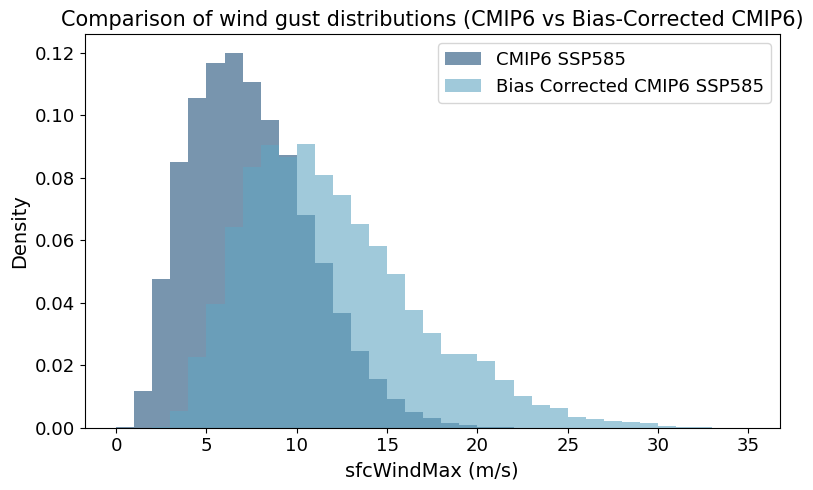

In [18]:
#Plot: CMIP6 data under SSP585 vs Bias-corrected CMIP6 data under SSP585
plot_df = df_merged_ssp585.copy()

fig, ax = plt.subplots(figsize=(8, 5))

bins = np.arange(0, max(plot_df["cmip6_gust_ms_585"].max(), plot_df["cmip6_gust_ms_bias_corr_585"].max()) + 1, 1)

ax.hist(
    plot_df["cmip6_gust_ms_585"],
    bins=bins,
    alpha=0.6,
    density=True,
    color=blue_dark,
    label="CMIP6 SSP585"
)

ax.hist(
    plot_df["cmip6_gust_ms_bias_corr_585"],
    bins=bins,
    alpha=0.6,
    density=True,
    color=blue_light,
    label="Bias Corrected CMIP6 SSP585"
)

ax.set_xlabel("sfcWindMax (m/s)", fontsize = 14)
ax.set_ylabel("Density", fontsize = 14)
ax.set_title("Comparison of wind gust distributions (CMIP6 vs Bias-Corrected CMIP6)", fontsize = 15)
ax.tick_params(axis='both', labelsize=13)
ax.legend(fontsize = 13)

plt.tight_layout()
plt.savefig("/Users/anne-sophiesimons/Documents/Data thesis/CMIP6_BiasCorrectedCMIP6", dpi=300)
plt.show()

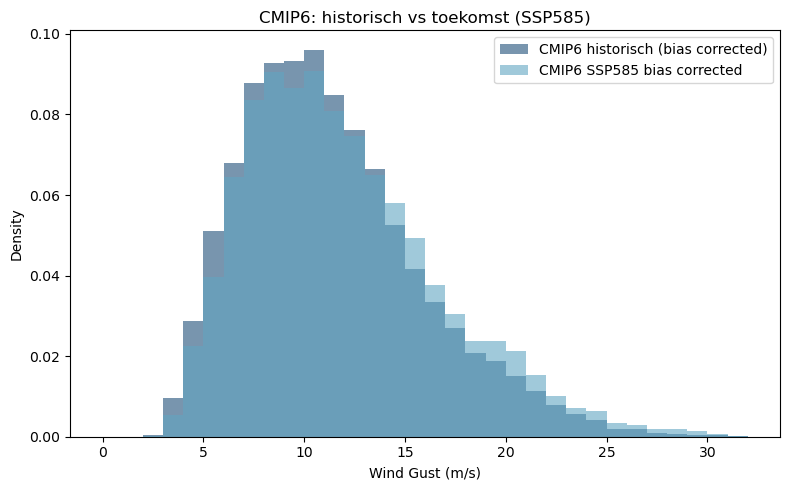

In [10]:
#Plot: CMIP6 historical data VS CMIP6 data under SSP585
import matplotlib.pyplot as plt
import numpy as np

plot_df = df_merged_ssp585.dropna()
plot_df_1 = df_merged_all.dropna()

fig, ax = plt.subplots(figsize=(8, 5))

bins = np.arange(
    0,
    max(
        plot_df_1["cmip6_gust_ms"].max(),
        plot_df_1["cmip6_bc_gust_ms"].max()
    ) + 1,
    1
)

#Historical CMIP6
ax.hist(
    plot_df_1["cmip6_bc_gust_ms"],
    bins=bins,
    alpha=0.6,
    density=True,
    label="CMIP6 historisch (bias corrected)",
    color=blue_dark,
)

#CMIP6 under SSP585
ax.hist(
    plot_df["cmip6_gust_ms_bias_corr_585"],
    bins=bins,
    alpha=0.6,
    density=True,
    label="CMIP6 SSP585 bias corrected",
    color=blue_light,
)

ax.set_xlabel("Wind Gust (m/s)")
ax.set_ylabel("Density")
ax.set_title("CMIP6: historisch vs toekomst (SSP585)")

ax.legend()

plt.tight_layout()
plt.savefig("/Users/anne-sophiesimons/Documents/Data thesis/historisch_toekomst", dpi=300)
plt.show()

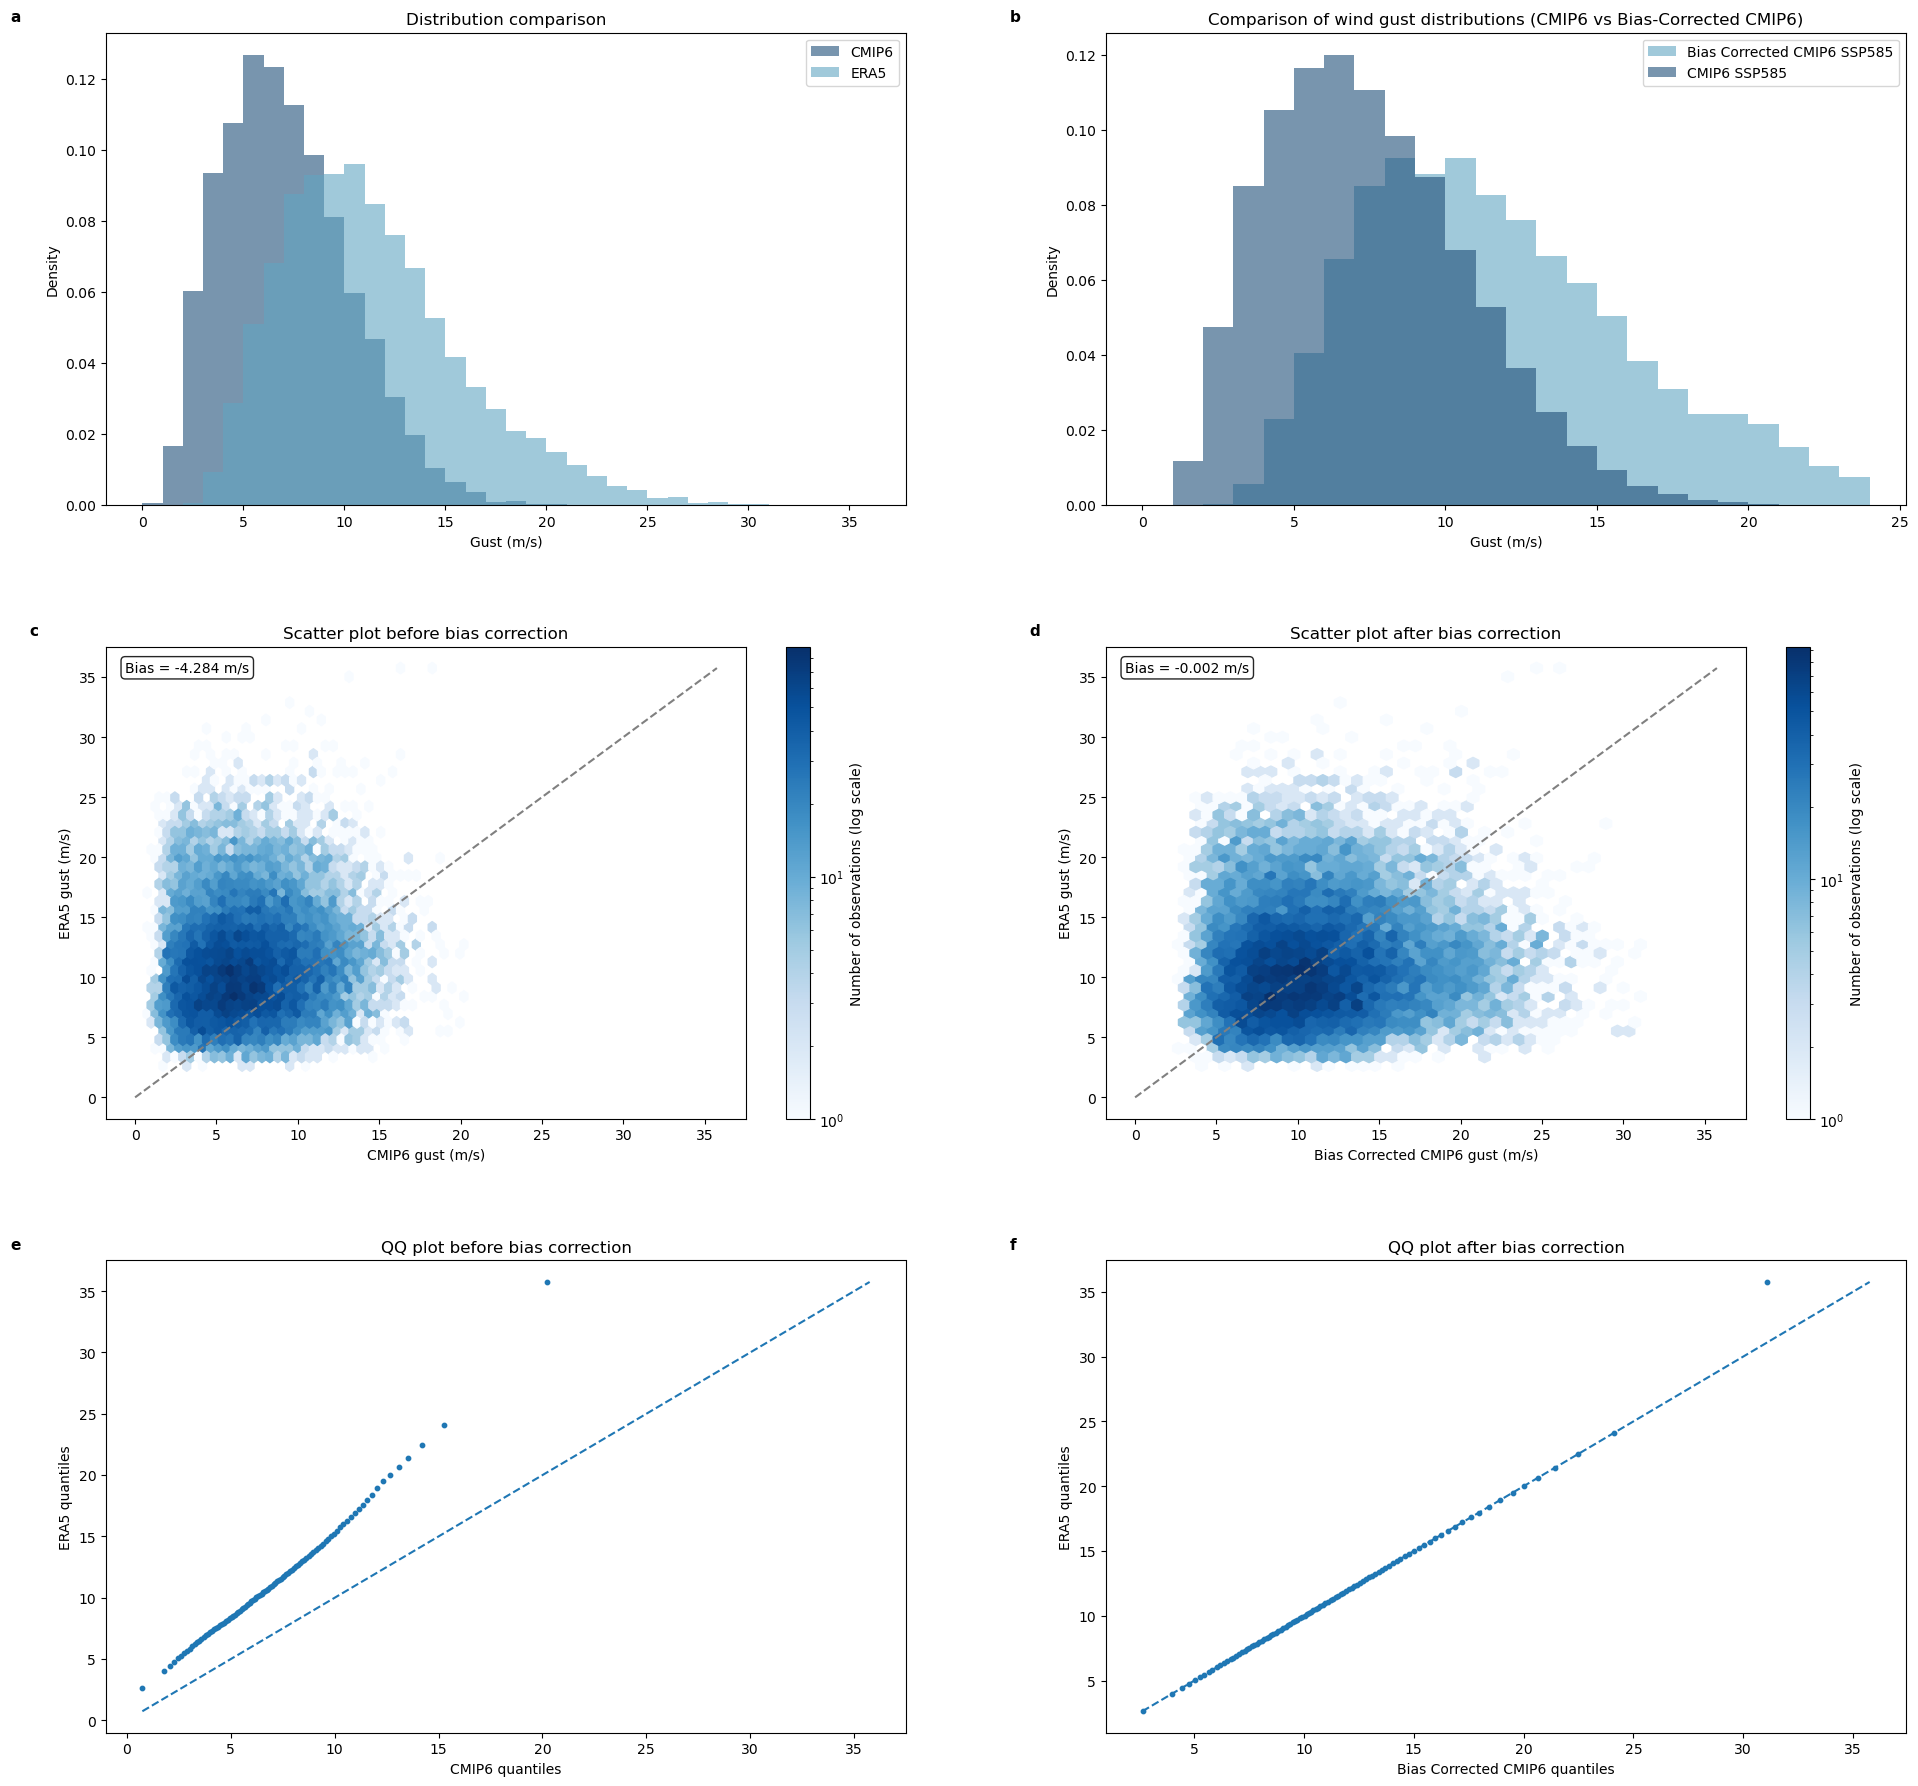

In [11]:
#All plots together in one figure
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(20, 20))

gs = gridspec.GridSpec(
    3, 2, figure=fig,
    hspace=0.3, wspace=0.25,
    left=0.07, right=0.97,
    top=0.93, bottom=0.08
)

ax1 = fig.add_subplot(gs[0, 0])  # histogram
ax2 = fig.add_subplot(gs[0, 1])  # hexbin CMIP6
ax3 = fig.add_subplot(gs[1, 0])  # hexbin BC
ax4 = fig.add_subplot(gs[1, 1])  # QQ plot
ax5 = fig.add_subplot(gs[2, 0])
ax6 = fig.add_subplot(gs[2, 1])

plot_df = df_merged_all

#Plot a: histogram
bins = np.arange(0, max(
    plot_df["cmip6_gust_ms"].max(),
    plot_df["era_gust_ms"].max()
) + 1, 1)

ax1.hist(plot_df["cmip6_gust_ms"], bins=bins, alpha=0.6, density=True, label="CMIP6", color=blue_dark)
ax1.hist(plot_df["era_gust_ms"], bins=bins, alpha=0.6, density=True, label="ERA5", color=blue_light)

ax1.set_xlabel("Gust (m/s)")
ax1.set_ylabel("Density")
ax1.set_title("Distribution comparison")
ax1.legend()

#Plot b: histogram (SSP585)
plot_df_2 = df_merged_ssp585.copy()
bins = np.arange(0, max(
    plot_df_2["cmip6_gust_ms_585"].max(),
    plot_df_2["cmip6_gust_ms_585"].max()
) + 1, 1)

ax2.hist(plot_df_2["cmip6_gust_ms_bias_corr_585"], bins=bins, alpha=0.6, density=True, label="Bias Corrected CMIP6 SSP585", color=blue_light)
ax2.hist(plot_df_2["cmip6_gust_ms_585"], bins=bins, alpha=0.6, density=True, label="CMIP6 SSP585", color=blue_dark)

ax2.set_xlabel("Gust (m/s)")
ax2.set_ylabel("Density")
ax2.set_title("Comparison of wind gust distributions (CMIP6 vs Bias-Corrected CMIP6)")
ax2.legend()

#Plot c: Hexbin CMIP6
max_val = max(
    plot_df["cmip6_gust_ms"].max(),
    plot_df["era_gust_ms"].max()
)

hb1 = ax3.hexbin(
    plot_df["cmip6_gust_ms"],
    plot_df["era_gust_ms"],
    gridsize=40,
    cmap="Blues",
    bins="log"
)

ax3.plot([0, max_val], [0, max_val], '--', color='grey')
ax3.set_xlabel("CMIP6 gust (m/s)")
ax3.set_ylabel("ERA5 gust (m/s)")
ax3.text(
    0.03, 0.97,
    f"Bias = {bias_all:.3f} m/s",
    transform=ax3.transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
)
ax3.set_title(f"Scatter plot before bias correction")
fig.colorbar(hb1, ax=ax3).set_label("Number of observations (log scale)")

#Plot d: Hexbin bias-corrected
hb2 = ax4.hexbin(
    plot_df["cmip6_bc_gust_ms"],
    plot_df["era_gust_ms"],
    gridsize=40,
    cmap="Blues",
    bins="log"
)

ax4.plot([0, max_val], [0, max_val], '--', color='grey')
ax4.set_xlabel("Bias Corrected CMIP6 gust (m/s)")
ax4.set_ylabel("ERA5 gust (m/s)")
ax4.text(
    0.03, 0.97,
    f"Bias = {bias_bc:.3f} m/s",
    transform=ax4.transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
)
ax4.set_title(f"Scatter plot after bias correction")
fig.colorbar(hb2, ax=ax4).set_label("Number of observations (log scale)")

#Plot e: QQ plot (CMIP6 vs ERA5)
q = np.linspace(0, 1, 100)

x = plot_df["cmip6_gust_ms"]
y = plot_df["era_gust_ms"]

ax5.scatter(np.quantile(x, q), np.quantile(y, q), s=10)

min_val = min(np.min(x), np.min(y))
max_val = max(np.max(x), np.max(y))

ax5.plot([min_val, max_val], [min_val, max_val], '--')

ax5.set_xlabel("CMIP6 quantiles")
ax5.set_ylabel("ERA5 quantiles")
ax5.set_title("QQ plot before bias correction")

#Plot f: QQ plot (CMIP6 vs ERA5)
q = np.linspace(0, 1, 100)

x = plot_df["cmip6_bc_gust_ms"]
y = plot_df["era_gust_ms"]

ax6.scatter(np.quantile(x, q), np.quantile(y, q), s=10)

min_val = min(np.min(x), np.min(y))
max_val = max(np.max(x), np.max(y))

ax6.plot([min_val, max_val], [min_val, max_val], '--')

ax6.set_xlabel("Bias Corrected CMIP6 quantiles")
ax6.set_ylabel("ERA5 quantiles")
ax6.set_title("QQ plot after bias correction")


#Labels (a), (b), ...
for ax, label in zip([ax1, ax2, ax3, ax4, ax5, ax6], ['a', 'b', 'c', 'd', 'e', 'f']):
    ax.text(-0.12, 1.05, label,
            transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='top')

plt.savefig(
    "/Users/anne-sophiesimons/Documents/Data thesis/combined_grid.png",
    dpi=300
)

plt.show()